In [1]:
# from investment_analyser.data_loader import DataLoader
from investment_analyser.portfolio import Portfolio
# import os
# import pandas as pd
# import requests
# import json
# from bs4 import BeautifulSoup
from investment_analyser.security import Security

In [3]:
# p = Portfolio()
folder = "C:/Users/joche/GitHub/investment/investment-analyser/data"
sec_filepath = folder + "/security/iShares-Nikkei-225-UCITS-ETF-JPY-Acc_fund.xlsx"
index_filepath = folder + "/index/iShares_Nikkei_225_UCITS_ETF_(Acc)-yahoo.csv"
sec = Security(sec_filepath, dist_fund=False, calc_mat=False)


In [26]:
excel = pd.read_excel("C:/Users/joche/GitHub/investment/investment-analyser/data/index/119010 - MSCI USA Consumer Staples Index  - FULL - 1998-12-31 - 2026-07-06  - Monthly.xlsx")
excel
time = excel["Unnamed: 0"][5:]
index_return = excel["Unnamed: 1"][5:]
time
timestamps = pd.to_datetime(time, format='%Y-%m-%d').apply(lambda x: x.timestamp())
index_return

5             100
6       97.997065
7       93.487876
8       91.979813
9       92.846541
          ...    
331    654.842576
332    604.930188
333     625.22627
334    602.390505
335     610.32524
Name: Unnamed: 1, Length: 331, dtype: object

In [2]:
sec = Security("C:/Users/joche/GitHub/investment/investment-analyser/data/security/iShares-Core-SP-500-UCITS-ETF-USD-Acc_fund.xlsx")

In [11]:
sec.inception

'19/May/2010'

In [ ]:
url = "https://www.msci.com/indexes/index/700999/msci-europe-minimum-volatility-index-eur"

response = requests.get(url, headers={"User-agent": "InkJDog"})
# pd.read_html(response.content)

In [30]:
response.content

b'<!DOCTYPE html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no"><title>Challenge Validation</title><link rel="stylesheet" type="text/css" href="/JEkwd8--k/vekHIyNoV/DI3/YArl-8/pD/DXQlFj8m/dj9dTn/B7M1hY"><script type="text/javascript">function cp_clge_done(){location.reload(true);}</script><script src="/JEkwd8--k/vekHIyNoV/DI3/YArl-8/pD/DXQlFj8m/MCl1TC/4RYGwt" async defer></script><script type="text/javascript">sessionStorage.setItem(\'data-duration\', 10);</script></head><body><div class="sec-container"><div id="sec-text-container"><iframe title="Challenge Message" id="sec-text-if" class="custmsg crypto" src="/JEkwd8--k/vekHIyNoV/DI3/YArl-8/pD/DXQlFj8m/d2t3Az/Q1VGQAAQ"></iframe></div><div id="sec-if-container"><iframe title="Challenge Content" id="sec-cpt-if" provider="crypto" class="crypto" challenge="eyJ0b2tlbiI6IkFBUUFBQUFOX19fX19fYzdqelBYamVOel9uVXBrWUhXRXJoeGg4dDF1a1RPbnVld0RzclFfQzJmenBMQmNqOEVaMmZ

In [25]:
url = "https://query2.finance.yahoo.com/v8/finance/chart/%5EFTSE?period1=-1325583000&period2=1724284800&interval=1d&events=history&includeAdjustedClose=true"

response = requests.get(url, headers={"User-agent": "InkJDog"})

In [28]:
from datetime import datetime

# Example timestamp (in seconds since epoch)
timestamp = 1227168000

# Convert to datetime object
dt_object = datetime.fromtimestamp(timestamp)
dt_object

datetime.datetime(2008, 11, 20, 8, 0)

In [27]:
js = json.loads(response.content)

df = pd.DataFrame(
    data={
        "Timestamp": js["chart"]["result"][0]["timestamp"],
        "Adj Close": js["chart"]["result"][0]["indicators"]["adjclose"][0]["adjclose"],
    },
    dtype=float,
)
df

,Timestamp,Adj Close
0,4.419648e+08,997.500000
1,4.420512e+08,998.599976
2,4.421376e+08,1015.799988
3,4.422240e+08,1029.000000
4,4.424832e+08,1034.599976
...,...,...
10443,1.723705e+09,8347.400391
10444,1.723792e+09,8311.400391
10445,1.724051e+09,8356.900391
10446,1.724137e+09,8273.299805


In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
soup

In [ ]:
soup.select_one("meta")

In [21]:

summary = soup.select_one("#quote-summary")
print(summary)
# tables = pd.read_html(str(summary))

# df = pd.concat(tables, axis=0, ignore_index=True)
# df.columns = ["Field", "Value"]

# print(df)

None


In [3]:
dl = DataLoader()

In [4]:
dl.xml_to_xlsx('C:/\Users\\joche\\Downloads\\STOXX-Europe-600-Utilities-UCITS-ETF-DE_fund.xls')

In [62]:
excel = pd.read_excel('C:\\Users\\joche\\Downloads\\STOXX-Europe-600-Utilities-UCITS-ETF-DE_fund.xlsx', sheet_name=[1,2,4], header=None)



In [65]:
excel[4]

,0,1,2
0,Ex-Date,Payable Date,Total Distribution
1,15/Jul/2026,15/Jul/2026,0.626892
2,15/Apr/2026,15/Apr/2026,0.226545
3,15/Jan/2026,15/Jan/2026,0.141646
4,15/Oct/2025,15/Oct/2025,0.370157
...,...,...,...
76,16/Jul/2007,16/Jul/2007,1.4302
77,17/Jul/2006,17/Jul/2006,0.8884
78,15/Jul/2005,15/Jul/2005,1.1359595
79,15/Jul/2004,15/Jul/2004,0.7202498


[1 2 4]
[ True  True  True]
[20 30 50]


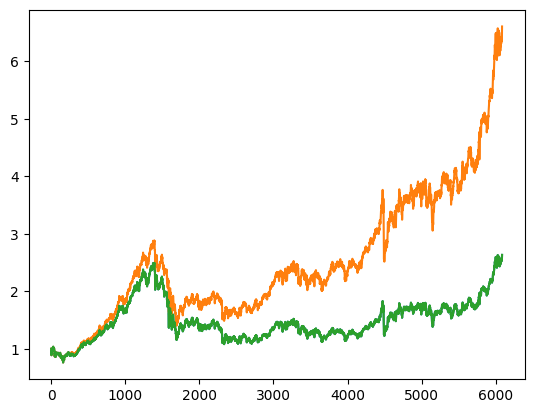

In [80]:
import matplotlib.pyplot as plt
import numpy as np

a = excel[2][2][1:]
c = excel[2][5][1:]
securities = excel[2][3][1:]
assets = excel[2][4][1:]

numeric_entries = np.logical_and(np.logical_and(~c.str.contains("-", na=False),~a.str.contains("-", na=False)),
                                 np.logical_and(~securities.str.contains("-", na=False),~assets.str.contains("-", na=False)))
a = np.asarray(a[numeric_entries][::-1],dtype=float)
a = a/a[0]

c = np.asarray(c[numeric_entries][::-1],dtype=float)
c = c/c[0]

securities = np.asarray(securities[numeric_entries][::-1],dtype=float)
assets = np.asarray(assets[numeric_entries][::-1],dtype=float)
assets_per_sec = assets/securities
assets_per_sec = assets_per_sec/assets_per_sec[0]

b = np.linspace(0,6085,a.shape[0])
# d = np.linspace(0,6085,760)
plt.plot(b,a)
plt.plot(b,c)
plt.plot(b,assets_per_sec)
plt.show()

In [92]:
orig_return = c
orig_tick_time = b

dividend_return = excel[4][2][1:]
dividend_tick_time = b[::-1]

# Remove entries with '--' and reverse order (from start to now)
numeric_entries_div = ~dividend_return.str.contains("-", na=False)
dividend_tick_time = dividend_tick_time[numeric_entries_div][::-1]
dividend_return = np.asarray(dividend_return[numeric_entries_div][::-1], dtype=float)

# Extract per security NAV in security currency
nav = excel[2][2][1:]
print(nav.shape, numeric_entries.shape)
nav = nav[numeric_entries][::-1]

# Align NAV values to the dividend dates in a vectorized way.
idx = np.searchsorted(orig_tick_time, dividend_tick_time)

# Check if the dividends do actually fall within the nav time-series (in principle
# it always should)
print(idx)
print(orig_tick_time)
print(orig_tick_time)
print(idx[-1],len(orig_tick_time))
if idx[-1] >= len(orig_tick_time):
    idx = idx[:-1]
    dividend_return = dividend_return[:-1]
    dividend_tick_time = dividend_tick_time[:-1]
print(idx)

if not np.all(orig_tick_time[idx] == dividend_tick_time):
    print(orig_tick_time[idx] == dividend_tick_time)
    print(orig_tick_time[idx[0]], dividend_tick_time[0])
    raise ValueError("Some dividend dates could not be matched to NAV dates.")

dividend_nav = np.asarray(nav[idx], dtype=float)
rel_dividend_return = dividend_return / dividend_nav

# Apply dividend effects to all subsequent returns in a vectorized way.
dividend_factors = np.ones(len(orig_return), dtype=float)
dividend_factors[idx] = rel_dividend_return
dividend_factors = np.cumprod(dividend_factors)
# orig_return = orig_return * dividend_factors

(6086,) (6086,)
[   0   77  154  231  308  385  461  538  615  692  769  845  922  999
 1076 1153 1229 1306 1383 1460 1537 1614 1690 1767 1844 1921 1998 2074
 2151 2228 2305 2382 2458 2535 2612 2689 2766 2842 2919 2996 3073 3150
 3227 3303 3380 3457 3534 3611 3687 3764 3841 3918 3995 4071 4148 4225
 4302 4379 4455 4532 4609 4686 4763 4840 4916 4993 5070 5147 5224 5300
 5377 5454 5531 5608 5684 5761 5838 5915 5992 6068]
[0.00000000e+00 1.00280158e+00 2.00560316e+00 ... 6.08299440e+03
 6.08399720e+03 6.08500000e+03]
[0.00000000e+00 1.00280158e+00 2.00560316e+00 ... 6.08299440e+03
 6.08399720e+03 6.08500000e+03]
6068 6069
[   0   77  154  231  308  385  461  538  615  692  769  845  922  999
 1076 1153 1229 1306 1383 1460 1537 1614 1690 1767 1844 1921 1998 2074
 2151 2228 2305 2382 2458 2535 2612 2689 2766 2842 2919 2996 3073 3150
 3227 3303 3380 3457 3534 3611 3687 3764 3841 3918 3995 4071 4148 4225
 4302 4379 4455 4532 4609 4686 4763 4840 4916 4993 5070 5147 5224 5300
 5377 5454 5531 56

ValueError: Some dividend dates could not be matched to NAV dates.

In [ ]:
name = excel[1][0][0]  # Name of the security
inception = excel[1][1][6]  # Inception data
inception_tick = convert_time(
    np.asarray([inception]), time_form="iShares"
)[0]
type = excel[1][1][10]
benchmark = excel[1][1][11]
currency = excel[1][1][8]

orig_tick_time = convert_time(np.asarray(excel[2][0][1:]), time_form="iShares")
orig_return = excel[2][2][1:]

# Remove entries with '--' and reverse order (from start to now)
numeric_entries = ~orig_return.str.contains("-", na=False)
orig_tick_time = orig_tick_time[numeric_entries][::-1]
orig_return = orig_return[numeric_entries][::-1]

# Turn array into float
orig_return = np.asarray(orig_return, dtype=float)